# Now analyze the data

In [8]:
library(tidyverse)
library(data.table)
library(pheatmap)
figure_outdir <- "/mnt/dawnccle2/melange/figures_outputs/fig06"

raw_df <- read.csv("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_denovoR2/denovoR2_all_samples_raw_counts.csv")
head(raw_df)

# Get the unique conditions.
unique_conditions <- unique(raw_df$condition)
print(unique_conditions)

# Get the unique samples.
unique_samples <- unique(raw_df$sample)
print(unique_samples)

# Get the unique indices.

,filename,index,offset_initial,design,mode,offset,count,count_scaled,sample,condition
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
1,/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-CH3-1-A1-rep1_S12_umi_dedup_fine_grained_idx.csv,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115,0:0:0,R2design0,INCLUDED,-44:0:0,9,9,CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1
2,/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-CH3-1-A1-rep1_S12_umi_dedup_fine_grained_idx.csv,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115,0:0:0,R2design0,INCLUDED,0:0:0,1,1,CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1
3,/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-CH3-1-A1-rep1_S12_umi_dedup_fine_grained_idx.csv,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115,0:0:0,R2design0,SKIPPED,0,54,54,CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1
4,/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-CH3-1-A1-rep1_S12_umi_dedup_fine_grained_idx.csv,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115,0:0:0,R2design0,UNSPLICED,0,8,8,CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1
5,/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-CH3-1-A1-rep1_S12_umi_dedup_fine_grained_idx.csv,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115,0:0:0,R2design0,UNSPLICED,1,1,1,CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1
6,/mnt/dawnccle2/processed_data/reprocess_250221/denovoR2_cancer//CANCERspecific-CH3-1-A1-rep1_S12_umi_dedup_fine_grained_idx.csv,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115,0:0:0,R2design0,UNSPLICED,113,27,27,CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1


 [1] "CANCERspecific-CH3-1-A1"    "CANCERspecific-Ch3-1-A2"   
 [3] "CANCERspecific-FUBP1-B12"   "CANCERspecific-FUBP1-C8"   
 [5] "CANCERspecific-RBM10-C8"    "CANCERspecific-RBM10-G4"   
 [7] "CANCERspecific-RBM5-A2"     "CANCERspecific-RBM5-A3"    
 [9] "CANCERspecific-SF3B1-K700E" "CANCERspecific-SF3B1-K700K"
[11] "CANCERspecific-U2AF1-S34F"  "CANCERspecific-U2AF1-WT"   
[13] "CANCERspecific-WT"          "CANCERspecific-ZRSR2-F8"   
[15] "CANCERspecific-ZRSR2-G9"    "KELLYspecific-A375"        
[17] "KELLYspecific-HEK"          "KELLYspecific-KELLY"       
[19] "KELLYspecific-T47D"        
 [1] "CANCERspecific-CH3-1-A1-rep1"    "CANCERspecific-CH3-1-A1-rep2"   
 [3] "CANCERspecific-Ch3-1-A2-rep1"    "CANCERspecific-Ch3-1-A2-rep2"   
 [5] "CANCERspecific-FUBP1-B12-rep1"   "CANCERspecific-FUBP1-B12-rep2"  
 [7] "CANCERspecific-FUBP1-C8-rep1"    "CANCERspecific-FUBP1-C8-rep2"   
 [9] "CANCERspecific-RBM10-C8-rep1"    "CANCERspecific-RBM10-C8-rep2"   
[11] "CANCERspecific-RBM10-G4-rep1

In [9]:
raw_df_clean <- raw_df %>%
    # Rename CANCERspecific-Ch3-1-A2 to CANCERspecific-CH3-1-A2 in both sample and condition
    mutate(sample = gsub("CANCERspecific-Ch3-1-A2", "CANCERspecific-CH3-1-A2", sample)) %>% 
    mutate(condition = gsub("CANCERspecific-Ch3-1-A2", "CANCERspecific-CH3-1-A2", condition)) %>% 
    mutate(index_offset = paste0(index, "__", offset_initial)) %>% 
    select(-filename, - index, - offset_initial) %>%
    filter(mode %in% c("INCLUDED", "SKIPPED")) %>% 
    group_by(sample, condition, index_offset, mode, offset, design) %>%
    summarise(count = sum(count)) %>% 
    arrange(sample, condition, index_offset, design)
head(raw_df_clean)

`summarise()` has grouped output by 'sample', 'condition', 'index_offset',
'mode', 'offset'. You can override using the `.groups` argument.


sample,condition,index_offset,mode,offset,design,count
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,INCLUDED,-44:0:0,R2design0,9
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,INCLUDED,0:0:0,R2design0,1
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,SKIPPED,0,R2design0,54
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,INCLUDED,-2:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design1,1
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,INCLUDED,0:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design1,703
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,INCLUDED,2:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design1,2


In [18]:
test <- raw_df_clean %>% filter(grepl("CANCERspecific-U2AF1-WT", condition))

unique(test$sample)

[1] "CANCERspecific-U2AF1-WT-rep1" "CANCERspecific-U2AF1-WT-rep2"
[3] "CANCERspecific-U2AF1-WT-rep3"

In [16]:
raw_df_to_psi <- raw_df_clean %>% 
    group_by(sample, condition, index_offset, mode, design) %>%
    summarise(count = sum(count)) %>% 
    ungroup() %>% 
    pivot_wider(names_from = mode, values_from = count, values_fill = 0) %>%
    mutate(total_counts = INCLUDED + SKIPPED) %>%
    filter(total_counts >= 30) %>%
    mutate(PSI = INCLUDED / total_counts)

head(raw_df_to_psi)

# Save this file
write.csv(raw_df_to_psi, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_denovoR2/denovoR2_all_samples_PSI_count_table.csv", row.names = FALSE)

`summarise()` has grouped output by 'sample', 'condition', 'index_offset',
'mode'. You can override using the `.groups` argument.


sample,condition,index_offset,design,INCLUDED,SKIPPED,total_counts,PSI
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,R2design0,10,54,64,0.15625000
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design1,719,692,1411,0.50956768
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design4,64,515,579,0.11053541
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design5,1,77,78,0.01282051
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design6,4,79,83,0.04819277
CANCERspecific-CH3-1-A1-rep1,CANCERspecific-CH3-1-A1,ENSG00000006025.12;OSBPL7;chr17-47808863-47808946-47808537-47808660-47809075-47809115__0:0:0,vae_cancer_U2AF1S34F_0_to_neg_R2design7,77,255,332,0.23192771


In [4]:
unique(raw_df_to_psi$condition)

[1] "CANCERspecific-CH3-1-A1"    "CANCERspecific-Ch3-1-A2"   
 [3] "CANCERspecific-FUBP1-B12"   "CANCERspecific-FUBP1-C8"   
 [5] "CANCERspecific-RBM10-C8"    "CANCERspecific-RBM10-G4"   
 [7] "CANCERspecific-RBM5-A2"     "CANCERspecific-RBM5-A3"    
 [9] "CANCERspecific-SF3B1-K700E" "CANCERspecific-SF3B1-K700K"
[11] "CANCERspecific-U2AF1-S34F"  "CANCERspecific-U2AF1-WT"   
[13] "CANCERspecific-WT"          "CANCERspecific-ZRSR2-F8"   
[15] "CANCERspecific-ZRSR2-G9"    "KELLYspecific-A375"        
[17] "KELLYspecific-HEK"          "KELLYspecific-KELLY"       
[19] "KELLYspecific-T47D"

# Analyze Kelly specific only

In [35]:
# Look at the kelly sequences only. 
raw_df_to_psi_kelly <- raw_df_to_psi %>% 
    filter(grepl("KELLYspecific", condition))
raw_df_to_psi_kelly <- raw_df_to_psi_kelly %>% 
    # filter(design != "R2design0") %>% 
    group_by(condition, index_offset, design) %>% 
    summarise(PSI = mean(PSI)) %>% 
    ungroup() %>% 
    select(condition, index_offset, design, PSI) %>% 
    pivot_wider(names_from = condition, values_from = PSI) %>% 
    mutate(index_offset_design = paste0(index_offset, "___", design))

# Convert to matrix. 
psi_kelly_mat <- as.matrix(raw_df_to_psi_kelly %>% select(-index_offset_design, -index_offset, -design))
rownames(psi_kelly_mat) <- raw_df_to_psi_kelly$index_offset_design

# Only keep rows that have <20% NA.
psi_kelly_mat <- psi_kelly_mat[rowMeans(is.na(psi_kelly_mat)) <= 0.2, ]

# pheatmap(psi_kelly_mat, cluster_rows = TRUE, cluster_cols = FALSE, show_colnames = TRUE, show_rownames = FALSE)

head(psi_kelly_mat)

`summarise()` has grouped output by 'condition', 'index_offset'. You can
override using the `.groups` argument.


,KELLYspecific-A375,KELLYspecific-HEK,KELLYspecific-KELLY,KELLYspecific-T47D
ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330__0:0:0___R2design0,0.9442034587,0.934651978,0.9641113527,0.9293169387
ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330__0:0:0___vae_Kelly_1_to_pos_R2design1,0.0023725402,0.001518528,0.0147895617,0.0058464175
ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330__0:0:0___vae_Kelly_1_to_pos_R2design10,0.0000000000,0.000000000,0.0050386670,0.0006038647
ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330__0:0:0___vae_Kelly_1_to_pos_R2design2,0.0017299657,0.001345044,0.0008996739,0.0015244775
ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330__0:0:0___vae_Kelly_1_to_pos_R2design3,0.0008840896,0.001501590,0.0022412080,0.0024019982
ENSG00000004534.15;RBM6;chr3-50068689-50068764-50066241-50066502-50075200-50075330__0:0:0___vae_Kelly_1_to_pos_R2design4,0.0012515409,0.001263872,0.0016759420,0.0007364045


# Get the PSI in Kelly vs the other cell types. 

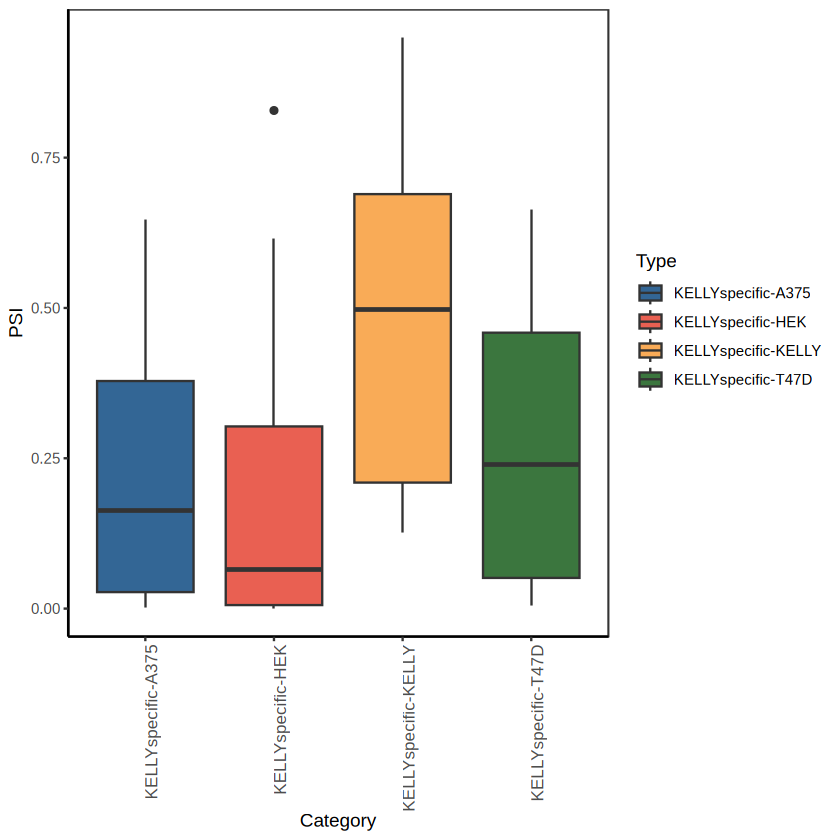

In [36]:
raw_df_to_psi_kelly_updated <- raw_df_to_psi_kelly %>% 
    filter(grepl("vae_Kelly_0_to_pos", design) | grepl("R2design0", design)) %>% 
    mutate(PSI_KELLY = `KELLYspecific-KELLY`) %>% 
    mutate(PSI_NON_KELLY = (`KELLYspecific-HEK` + `KELLYspecific-A375` + `KELLYspecific-T47D`)/3) %>%
    # Filter out the NA values.
    filter(!is.na(PSI_KELLY) | !is.na(PSI_NON_KELLY))

parent_sequences <- raw_df_to_psi_kelly_updated %>% 
    filter(design == "R2design0") 

parent_blacklist <- parent_sequences %>% 
    filter(abs(PSI_NON_KELLY - PSI_KELLY) > 0.1)

parent_whitelist <- parent_sequences %>% 
    filter(abs(PSI_NON_KELLY - PSI_KELLY) <= 0.1)

designed_sequences <- raw_df_to_psi_kelly_updated %>% 
    filter(design != "R2design0") %>%
    filter(!index_offset %in% parent_blacklist$index_offset) %>% 
    mutate(KELLY_diff = PSI_KELLY - PSI_NON_KELLY)

# ggplot(designed_sequences, aes(x = `KELLYspecific-A375`, y = `KELLYspecific-KELLY`)) +
#     geom_point() +
#     theme_minimal() 
#    filter(abs(PSI_NON_KELLY - PSI_KELLY) > 0.2)
# head(parent_sequences)

# Get the PSI in Kelly vs the other cell types. 
# head(designed_sequences %>% arrange(desc(KELLY_diff)))

# Get proportion of design sequences where KELLY_diff > 0.1.

percent_design_sequences_KELLY_diff_0.1 <- designed_sequences %>% 
    filter(abs(KELLY_diff) >= 0.1) %>% 
    nrow() / nrow(designed_sequences)

# Shortlist the specific sequences
specific_sequences <- designed_sequences %>% 
    filter(abs(KELLY_diff) >= 0.1) 
    
specific_sequences_to_plot <- specific_sequences %>% 
    select(index_offset_design, `KELLYspecific-HEK`, `KELLYspecific-A375`, `KELLYspecific-T47D`, `KELLYspecific-KELLY`) %>% 
    pivot_longer(cols = -index_offset_design, names_to = "cell_type", values_to = "PSI")


color_palette3 <- c(
"#336695",
"#E96052",
"#F9AB57",
"#3b763e")

ggplot(specific_sequences_to_plot, aes(x = cell_type, y = PSI, fill = cell_type)) +
    geom_boxplot() +
  theme_bw() +
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        strip.text = element_text(size = 12),
        axis.text.x = element_text(angle = 90, hjust = 1, size = 10)) +
  xlab("Category") +
  ylab("PSI") +
  labs(fill = "Type") +
  scale_fill_manual(values = color_palette3)

ggsave(file.path(figure_outdir, "fig06_PSI_boxplot_kelly_vs_rest.pdf"), width = 800, height = 500, units = "px", dpi = 150)

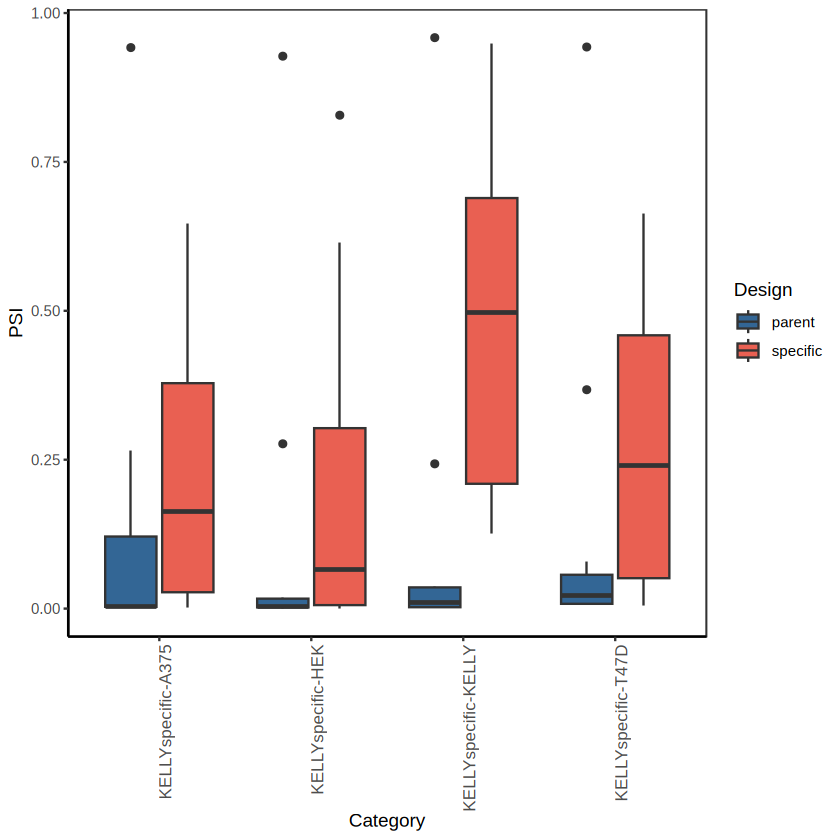

In [37]:
# specific_sequences
parent_whitelist_long <- parent_whitelist %>% 
    filter(index_offset %in% specific_sequences$index_offset) %>% 
    select(index_offset, design, `KELLYspecific-HEK`, `KELLYspecific-A375`, `KELLYspecific-T47D`, `KELLYspecific-KELLY`) %>% 
    mutate(design = "parent") %>% 
    pivot_longer(cols = c(-index_offset, -design), names_to = "cell_type", values_to = "PSI")


specific_sequences_long <- specific_sequences %>% 
    select(index_offset, design, `KELLYspecific-HEK`, `KELLYspecific-A375`, `KELLYspecific-T47D`, `KELLYspecific-KELLY`) %>% 
    mutate(design = "specific") %>% 
    pivot_longer(cols = c(-index_offset, -design), names_to = "cell_type", values_to = "PSI")

combined_long <- bind_rows(parent_whitelist_long, specific_sequences_long)

color_palette3 <- c(
"#336695",
"#E96052",
"#F9AB57",
"#3b763e")

ggplot(combined_long, aes(x = cell_type, y = PSI, fill = design)) +
    geom_boxplot() +
    theme_bw() +
    theme(axis.line = element_line(colour = "black"),
          panel.grid.major = element_blank(),
          panel.grid.minor = element_blank(),
          panel.background = element_blank(),
          strip.text = element_text(size = 12),
          axis.text.x = element_text(angle = 90, hjust = 1, size = 10)) +
    xlab("Category") +
    ylab("PSI") +
    labs(fill = "Design") +
    scale_fill_manual(values = color_palette3)

ggsave(file.path(figure_outdir, "fig06_PSI_boxplot_parent_vs_specific.pdf"), width = 800, height = 500, units = "px", dpi = 150)



# Plot Heatmap of sequences

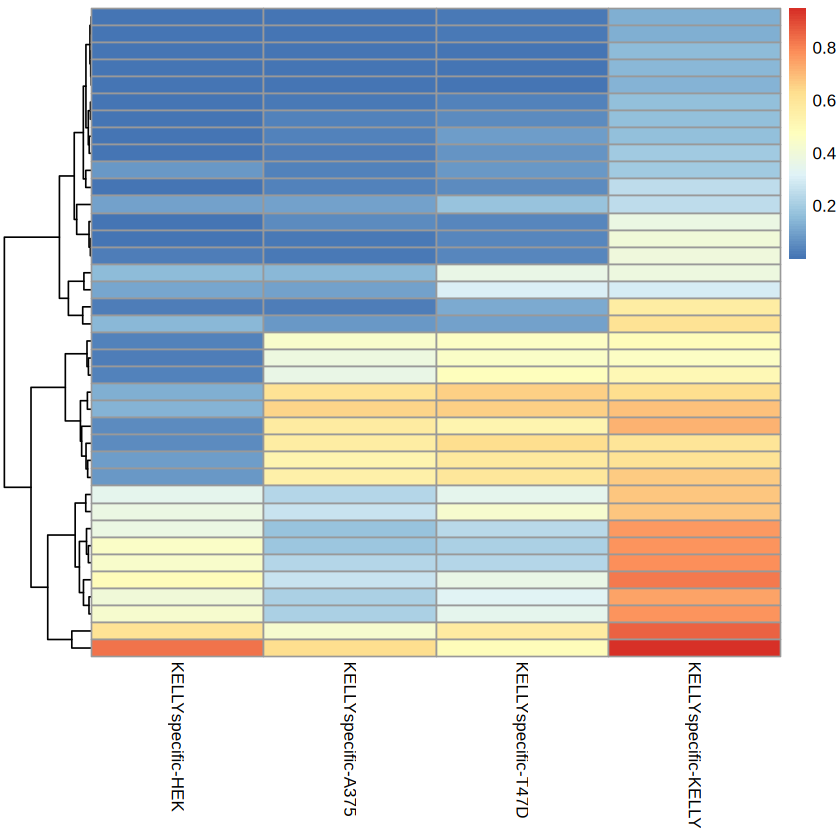

In [41]:
specific_sequences_mat <- specific_sequences %>% 
    select(`KELLYspecific-HEK`, `KELLYspecific-A375`, `KELLYspecific-T47D`, `KELLYspecific-KELLY`) %>% 
    as.matrix()
rownames(specific_sequences_mat) <- specific_sequences$index_offset_design

# Plot the heatmap. 
pheatmap(specific_sequences_mat, cluster_rows = TRUE, cluster_cols = FALSE, show_colnames = TRUE, show_rownames = FALSE)


In [12]:
designed_sequences

index_offset,design,KELLYspecific-A375,KELLYspecific-HEK,KELLYspecific-KELLY,KELLYspecific-T47D,index_offset_design,PSI_KELLY,PSI_NON_KELLY,KELLY_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0,vae_Kelly_0_to_pos_R2design1,0.0013547833,0.0012103440,0.0001133787,0.0019938376,ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0___vae_Kelly_0_to_pos_R2design1,0.0001133787,0.0015196550,-0.0014062763
ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0,vae_Kelly_0_to_pos_R2design2,0.0035614681,0.0019548525,0.0000000000,0.0008130081,ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0___vae_Kelly_0_to_pos_R2design2,0.0000000000,0.0021097763,-0.0021097763
ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0,vae_Kelly_0_to_pos_R2design3,0.0023965736,0.0012455842,0.0001819505,0.0017752715,ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0___vae_Kelly_0_to_pos_R2design3,0.0001819505,0.0018058098,-0.0016238593
ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0,vae_Kelly_0_to_pos_R2design4,0.0026511024,0.0013867621,0.0004527399,0.0027409544,ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0___vae_Kelly_0_to_pos_R2design4,0.0004527399,0.0022596063,-0.0018068664
ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0,vae_Kelly_0_to_pos_R2design5,0.0024843632,0.0015792539,0.0000000000,0.0014391283,ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0___vae_Kelly_0_to_pos_R2design5,0.0000000000,0.0018342485,-0.0018342485
ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0,vae_Kelly_0_to_pos_R2design6,0.0016578020,0.0009428931,0.0002092632,0.0008509467,ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0___vae_Kelly_0_to_pos_R2design6,0.0002092632,0.0011505473,-0.0009412841
ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0,vae_Kelly_0_to_pos_R2design7,0.0041402359,0.0011368936,0.0002968240,0.0030802025,ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0___vae_Kelly_0_to_pos_R2design7,0.0002968240,0.0027857773,-0.0024889534
ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0,vae_Kelly_0_to_pos_R2design8,0.0022446551,0.0011134710,0.0001090037,0.0016782965,ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0___vae_Kelly_0_to_pos_R2design8,0.0001090037,0.0016788075,-0.0015698038
ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0,vae_Kelly_0_to_pos_R2design9,0.0034059848,0.0015633907,0.0001790190,0.0027131454,ENSG00000009950.16;MLXIPL;chr7-73607378-73607420-73606973-73607018-73607589-73607672__0:0:0___vae_Kelly_0_to_pos_R2design9,0.0001790190,0.0025608403,-0.0023818213


# Plot cummulative density

In [106]:
# First look at how many of the seqeunces can lead to diff between Kelly and non-Kelly. 
final_psi_table_filtered <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table_major_events.csv")
final_psi_table_filtered <- final_psi_table_filtered %>% 
  filter(!(condition %in% c("K562WT", "K562K700E"))) %>% 
  filter(!(condition %in% c("JHOM1", "RVH421", "KNS60", "OVTOKO"))) %>% 
  mutate(total_count = included_count + skipped_count) %>%
  filter(total_count >= 30) %>%
  mutate(index_offset = paste(index, offset, sep = "__")) %>% 
  separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":") %>% 
  mutate(upstream_offset = as.integer(upstream_offset)) %>% 
  mutate(downstream_offset = as.integer(downstream_offset)) %>%
  mutate(const_offset = as.integer(const_offset)) %>% 
  filter(abs(upstream_offset) != 1 & abs(downstream_offset)!= 1) %>% 
  dplyr::select(-upstream_offset, -downstream_offset, -const_offset) %>% 
  dplyr::select(-index, -mode) %>%
  mutate(PSI = included_count/(included_count + skipped_count))
# Filter out the sequences that are in the blacklist.
blacklist_sequences <- read.csv("/mnt/dawnccle2/melange/process_fastq_250221/03_convert_to_PSI/WT_all_samples_blacklist_sequences.csv")
final_psi_table_filtered <- final_psi_table_filtered %>% 
  filter(!(index_offset %in% blacklist_sequences$index_offset))


dt <- as.data.table(final_psi_table_filtered)

# Compute PSI by condition efficiently
psi_by_condition <- dt[, .(PSI = mean(PSI, na.rm = TRUE), num_rep = .N), by = .(condition, index_offset)][
  num_rep >= 2, .(condition, index_offset, PSI)]  # Filter out groups with <2 replicates

psi_table_pivot <- psi_by_condition %>%
  select(condition, index_offset, PSI) %>%
  pivot_wider(names_from = c(condition), values_from = PSI)

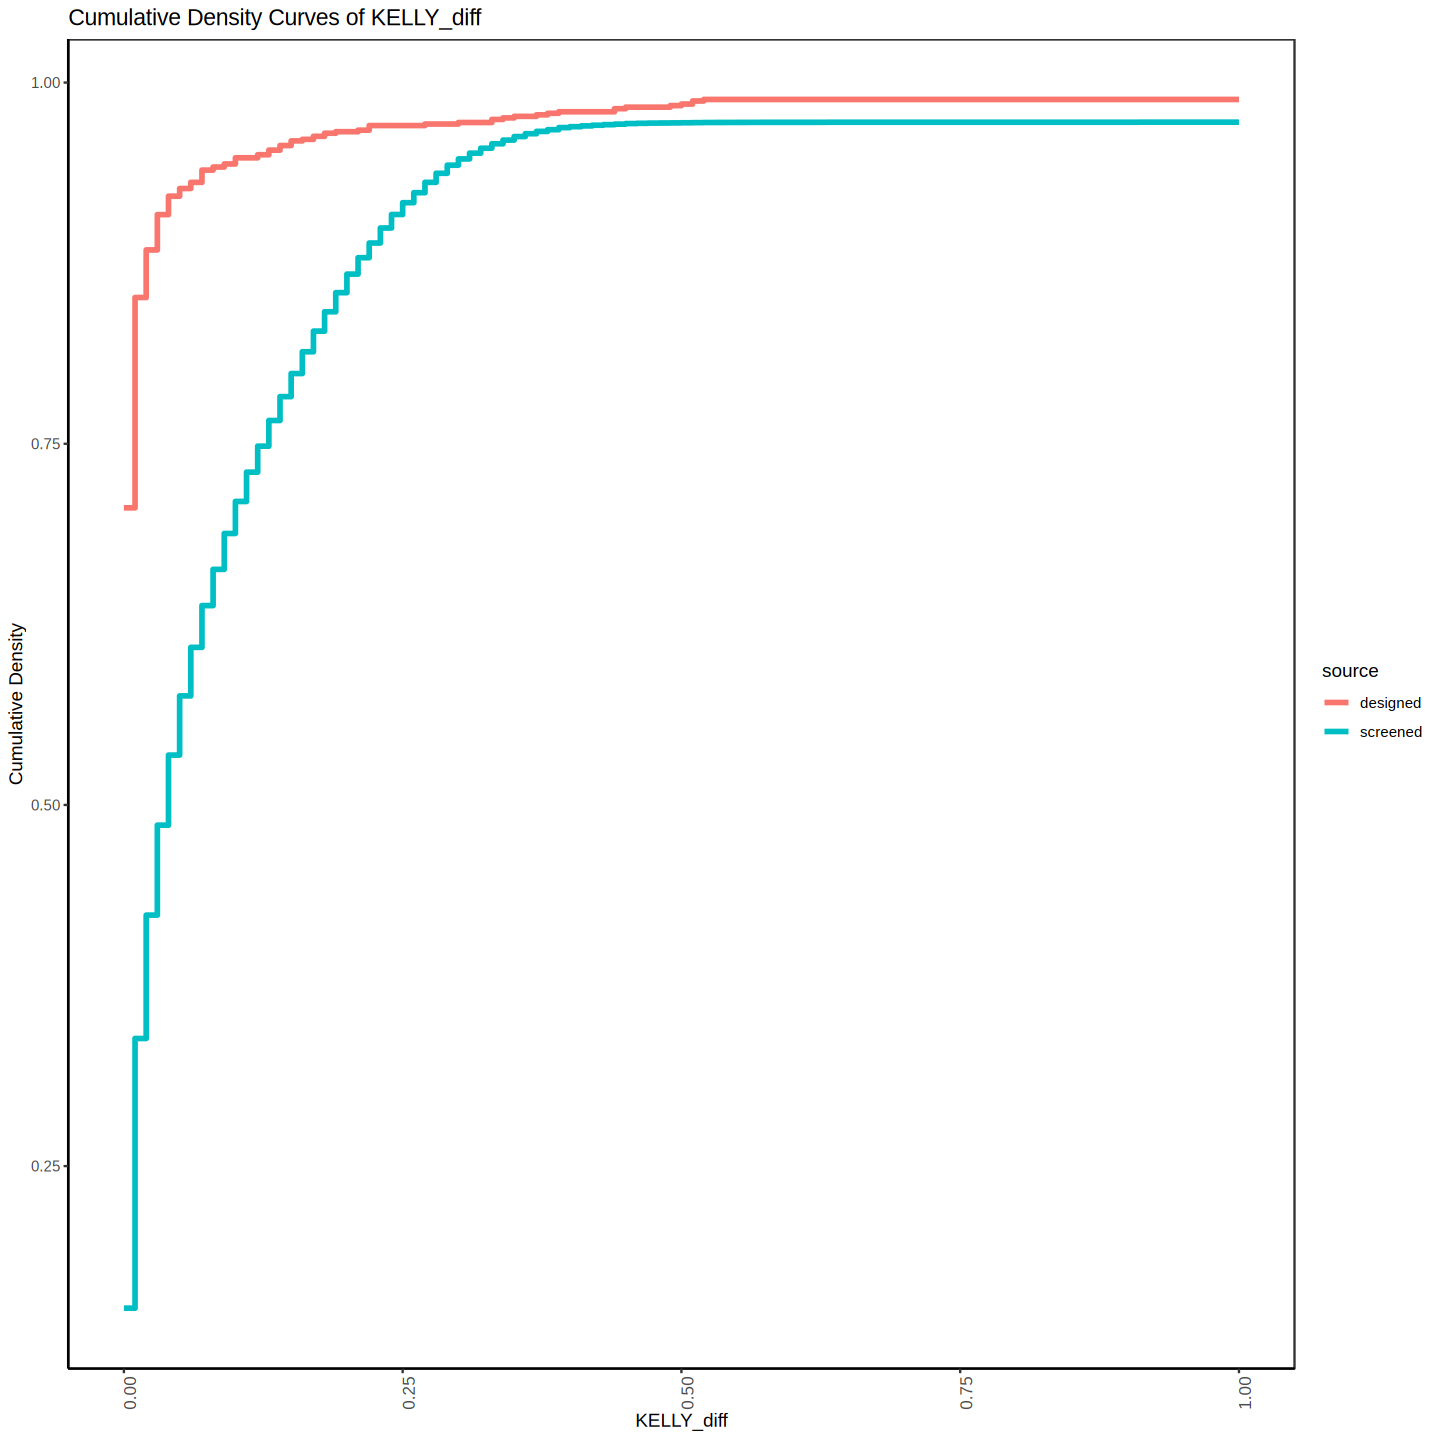

In [116]:
psi_table_pivot_with_kelly <- psi_table_pivot %>% 
    rowwise() %>%
    mutate(PSI_NON_KELLY = mean(c_across(-c(index_offset, Kelly)), na.rm = TRUE)) %>%
    ungroup() %>%
    mutate(PSI_KELLY = Kelly) %>%
    mutate(KELLY_diff = PSI_KELLY - PSI_NON_KELLY) %>% 
    select(index_offset, KELLY_diff)


designed_sequences_cummulative <- designed_sequences %>% 
    select(index_offset_design, KELLY_diff)


psi_df <- psi_table_pivot_with_kelly %>%
  mutate(source = "screened_sequences")

design_df <- designed_sequences_cummulative %>%
  rename(index_offset = index_offset_design) %>%
  mutate(source = "designed_sequences")

# Combine into one dataframe
combined_df <- bind_rows(psi_df, design_df)

# Make a seq of 0 to 1 by 0.01.
seq_0_to_1 <- seq(0, 1, 0.01)

df_0_to_1 <- data.frame(cutoff = seq_0_to_1, screened = NA, designed = NA)

# For each of the seq_0_to_1, get the cummulative density of the screened and designed.
for (i in 1:length(seq_0_to_1)) {
  df_0_to_1$screened[i] <- sum(psi_df$KELLY_diff <= seq_0_to_1[i], na.rm = TRUE) / nrow(psi_df)
  df_0_to_1$designed[i] <- sum(design_df$KELLY_diff <= seq_0_to_1[i], na.rm = TRUE) / nrow(design_df)
}
df_0_to_1 <- df_0_to_1 %>% 
    pivot_longer(cols = -cutoff, names_to = "source", values_to = "cummulative_density")

# Plot cumulative density (ECDF)
ggplot(df_0_to_1, aes(x = cutoff, y = cummulative_density, color = source)) +
  geom_step(size = 1.2) +
  labs(
    x = "KELLY_diff",
    y = "Cumulative Density",
    title = "Cumulative Density Curves of KELLY_diff"
  ) +
  scale_x_continuous(limits = c(0, 1)) + 
  theme_bw() +
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        strip.text = element_text(size = 12),
        axis.text.x = element_text(angle = 90, hjust = 1, size = 10))

ggsave(file.path(figure_outdir, "fig06_cumulative_density_KELLY_diff.pdf"), width = 800, height = 500, units = "px", dpi = 150)


Warning message:
“Removed 178 rows containing missing values or values outside the scale range
(`geom_point()`).”


[1] 2245

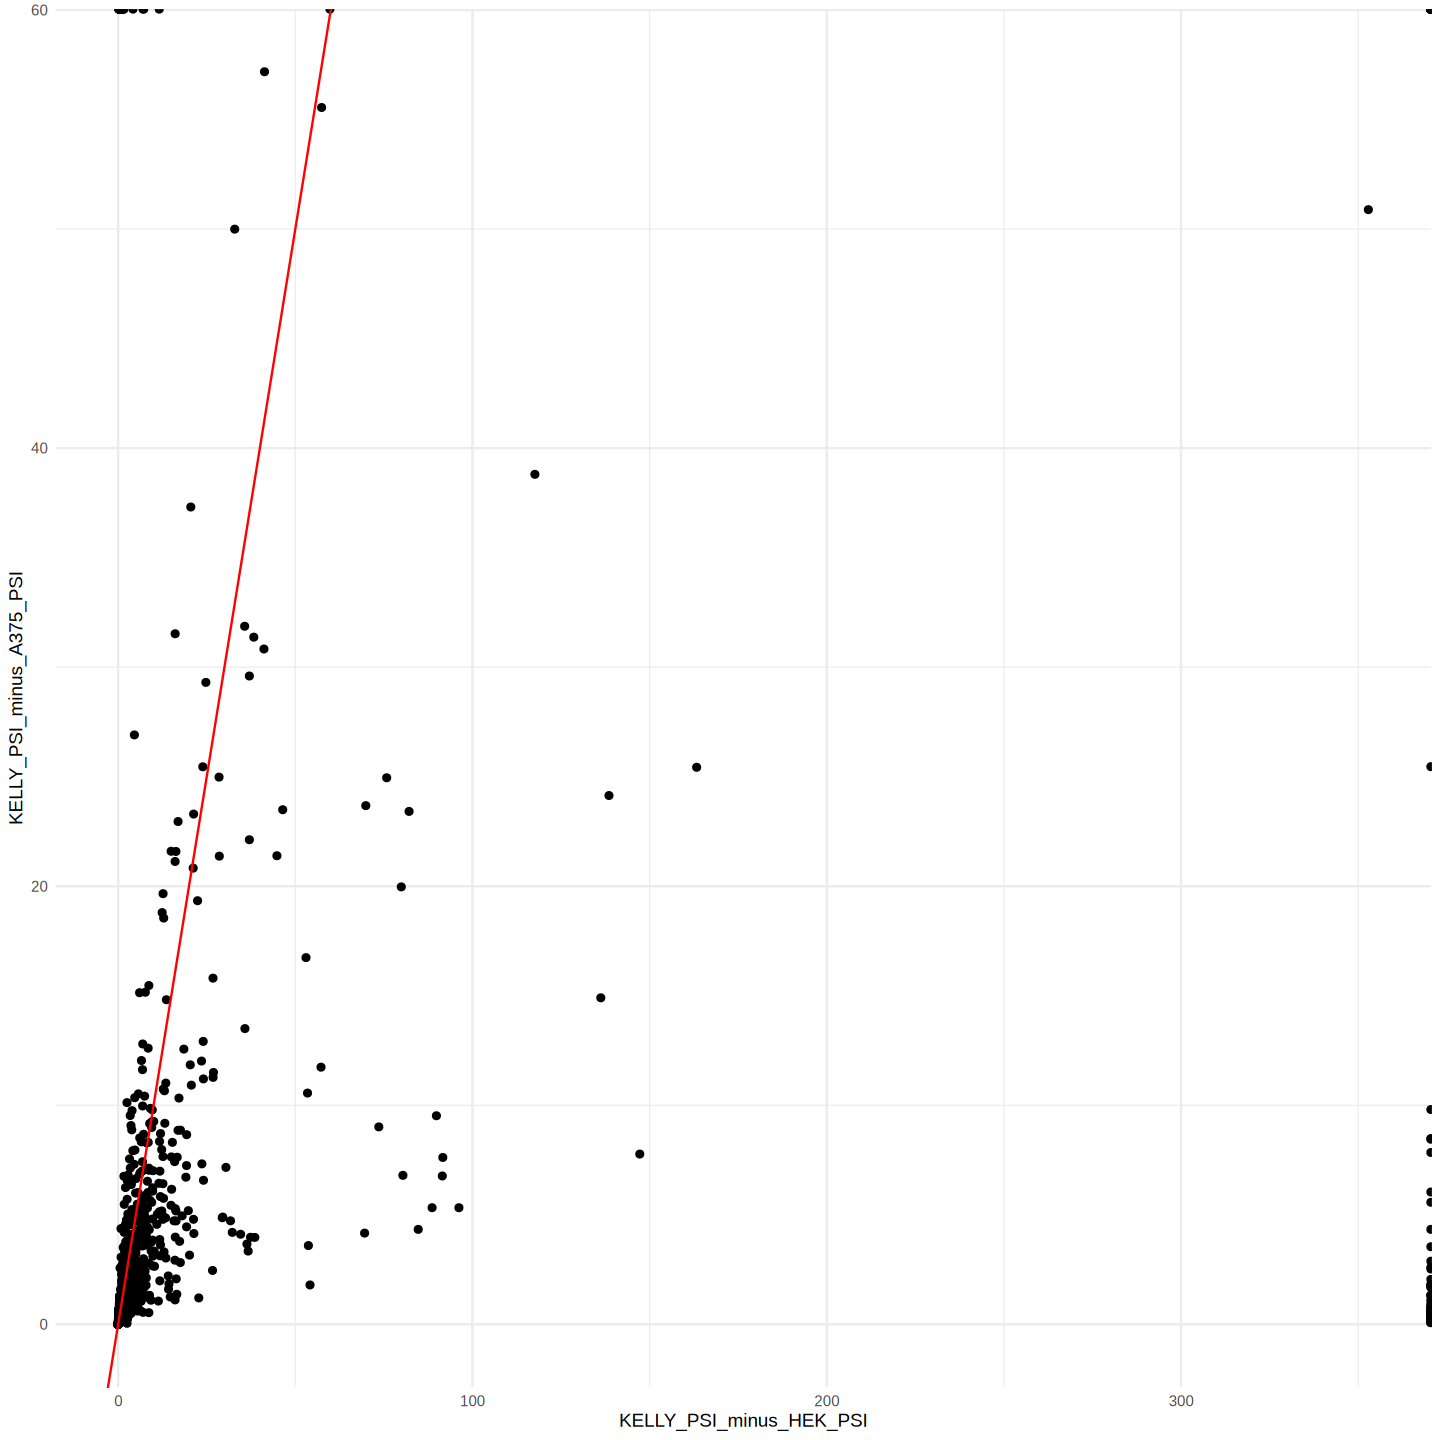

In [9]:
raw_df_to_psi_kelly_filtered <- raw_df_to_psi_kelly %>% 
    mutate(KELLY_PSI_minus_HEK_PSI = `KELLYspecific-KELLY`/`KELLYspecific-HEK`) %>% 
    mutate(KELLY_PSI_minus_A375_PSI = `KELLYspecific-KELLY`/`KELLYspecific-A375`) 

options(repr.plot.width=12, repr.plot.height=12)
ggplot(raw_df_to_psi_kelly_filtered, aes(x = KELLY_PSI_minus_HEK_PSI, y = KELLY_PSI_minus_A375_PSI)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red") +
    theme_minimal() 

nrow(raw_df_to_psi_kelly)

# raw_df_to_psi_kelly %>% 
#     filter(KELLY_HEK_diff > 0.2 & KELLY_A375_diff > 0.2)


# raw_df_to_psi_kelly %>% 
#     filter(KELLY_HEK_diff > 0.2 & KELLY_A375_diff > 0.2)

In [1]:
# raw_df_to_psi_kelly %>% filter(grepl("Kelly_1_to_neg", index_offset_design))

# Now look at cancer specific 

In [1]:
library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)

# Look at the kelly sequences only. 

raw_df_to_psi_cancer <- raw_df_to_psi %>% 
    filter(grepl("CANCERspecific", condition))
# raw_df_to_psi_cancer 

raw_df_to_psi_cancer <- raw_df_to_psi_cancer %>% 
    filter(design != "R2design0") %>% 
    group_by(condition, index_offset, design) %>% 
    summarise(PSI = mean(PSI)) %>% 
    ungroup() %>% 
    select(condition, index_offset, design, PSI) %>% 
    pivot_wider(names_from = condition, values_from = PSI) %>% 
    mutate(index_offset_design = paste0(index_offset, "___", design))

# Convert to matrix. 
# psi_cancer_mat <- as.matrix(raw_df_to_psi_cancer %>% select(-index_offset_design, -index_offset, -design))
# rownames(psi_cancer_mat) <- raw_df_to_psi_cancer$index_offset_design

# pheatmap(psi_cancer_mat, cluster_rows = FALSE, cluster_cols = FALSE, show_colnames = TRUE, show_rownames = FALSE)

# # head(psi_cancer_mat)
# raw_df_to_psi_cancer

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘vroom’


The following objects are masked from ‘package:readr’:

    as.col_spec, col_character, col_date, col_datetime, col_double,
    col_factor, col_guess, col_integer, col_logical, col_number,
    col_skip, col_time, cols, cols_condense, cols_only, date_names,
    date_names_lang, date_names_langs, default_locale, fwf_cols,
    fwf_empty, fwf_positions, fwf_widths, locale, output_column,
    problems, spec



Attaching package: ‘data.table’


The

ERROR: Error: object 'raw_df_to_psi' not found


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
“Removed 67 rows containing non-finite outside the scale range (`stat_bin()`).”


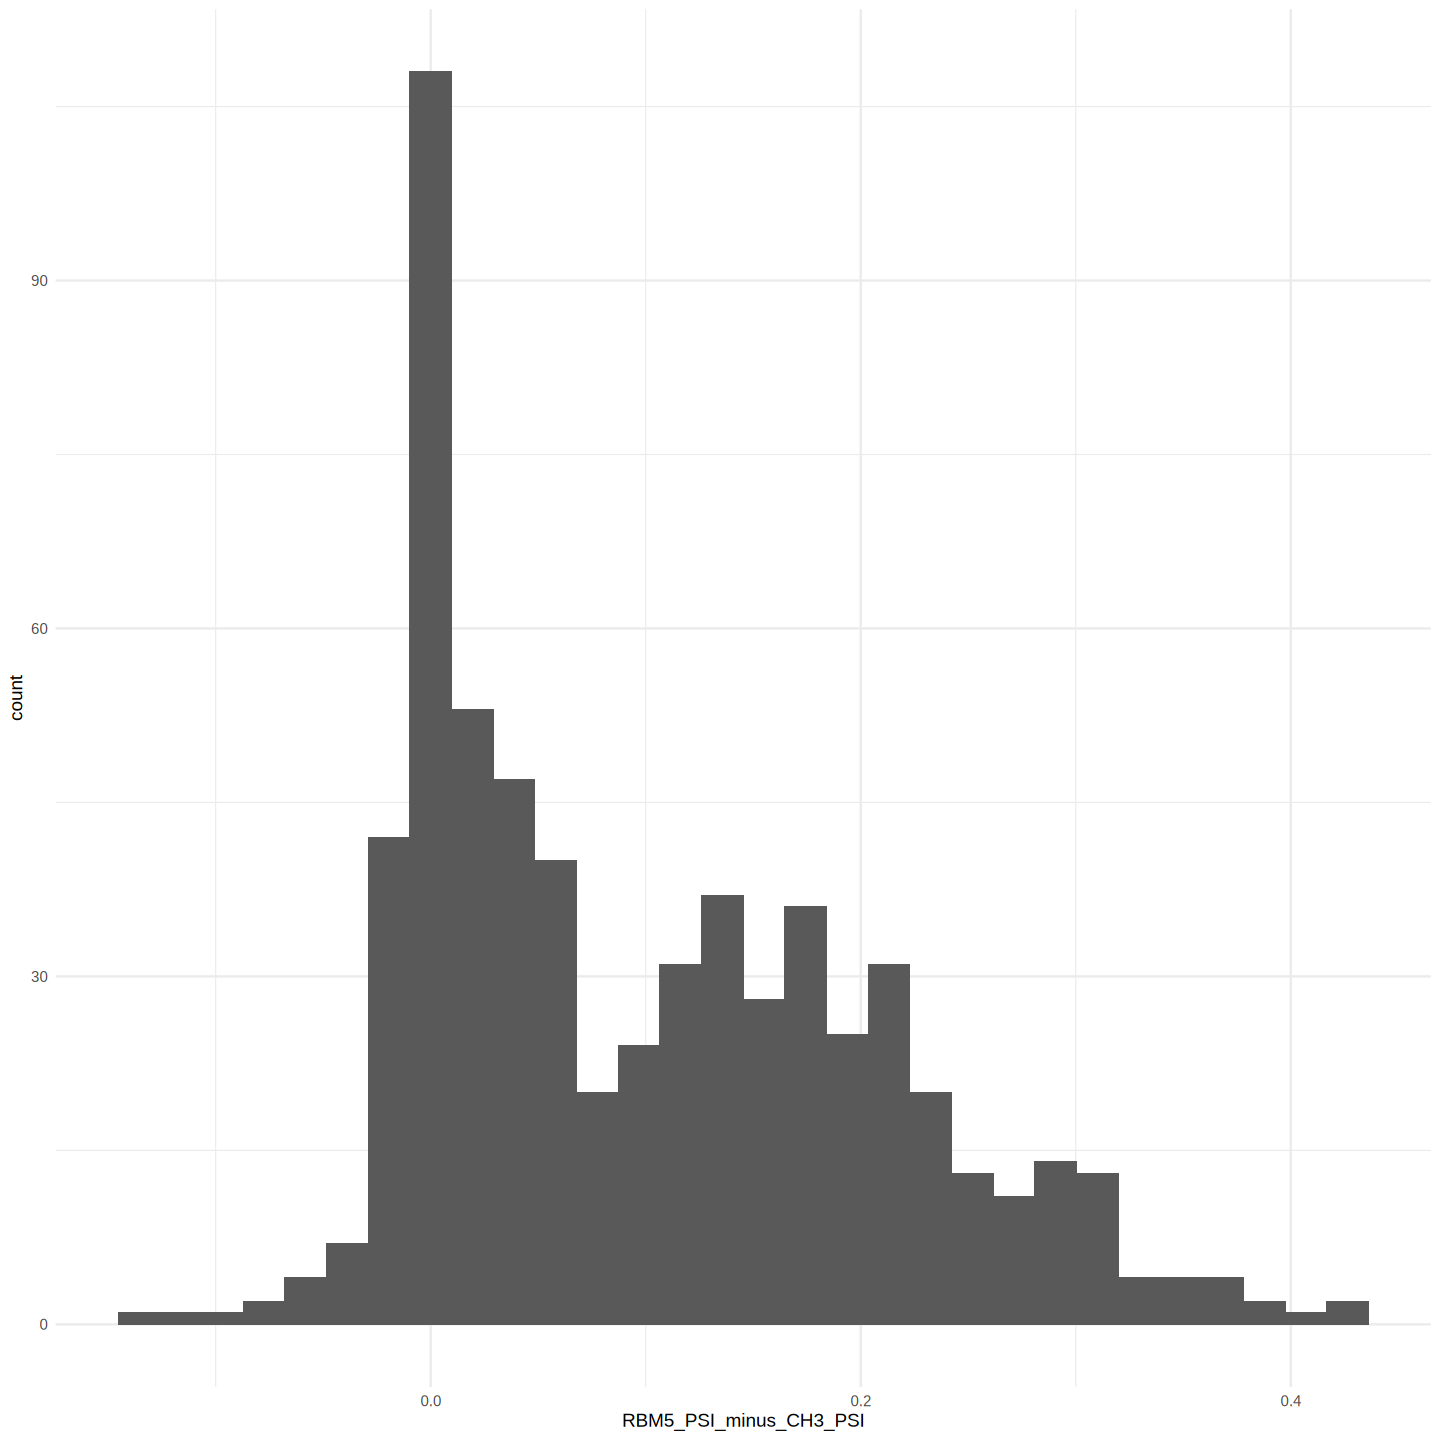

In [16]:
raw_df_to_psi_cancer_filtered <- raw_df_to_psi_cancer %>% 
    filter(grepl("vae_cancer_RBM5_0_to_pos",design)) %>% 
    mutate(RBM5_PSI_minus_CH3_PSI = `CANCERspecific-RBM5-A2` - `CANCERspecific-CH3-1-A1`)  %>%
    mutate(RBM5_PSI_FC_CH3_PSI = `CANCERspecific-RBM5-A2` / `CANCERspecific-CH3-1-A1`)


filtered_df <- raw_df_to_psi_cancer_filtered %>% 
    filter(abs(RBM5_PSI_minus_CH3_PSI) > 0.2)

options(repr.plot.width=12, repr.plot.height=12)
ggplot(raw_df_to_psi_cancer_filtered, aes(x = RBM5_PSI_minus_CH3_PSI)) +
    geom_histogram() +
    # geom_vline(xintercept = 0, color = "red") +
    theme_minimal() 

# filtered_df %>% arrange(desc(RBM5_PSI_FC_CH3_PSI))

# raw_df_to_psi_kelly %>% 
#     filter(KELLY_HEK_diff > 0.2 & KELLY_A375_diff > 0.2)


# raw_df_to_psi_kelly %>% 
#     filter(KELLY_HEK_diff > 0.2 & KELLY_A375_diff > 0.2)


